#Coleta de dados

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

In [3]:
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
display(df.describe())
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Linhas: 32581
Colunas: 12


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


None

In [6]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [7]:
display(df.dtypes)

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


##Gráficos

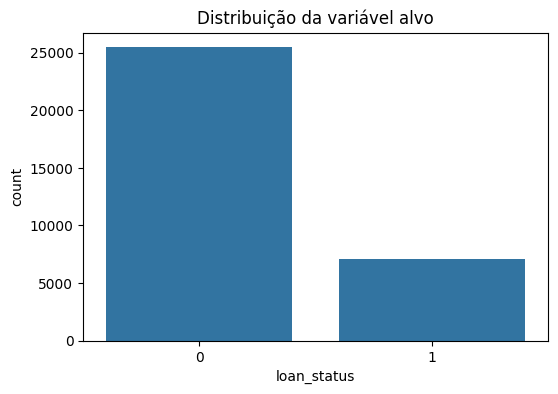

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')
plt.title("Distribuição da variável alvo")
plt.show()
#Observa-se que a variável alvo apresenta desbalanceamento entre clientes inadimplentes e adimplentes.
#Esse comportamento pode prejudicar algoritmos supervisionados, tornando necessária a aplicação de técnicas de balanceamento na etapa de preparação dos dados.

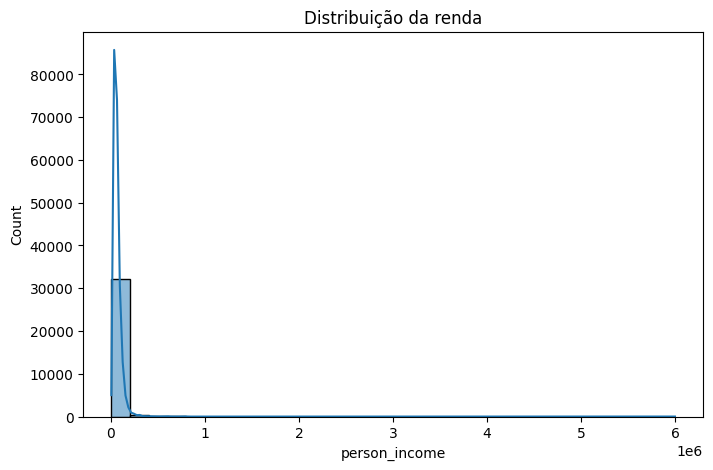

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["person_income"], bins=30,kde=True)
plt.title("Distribuição da renda")
plt.show()

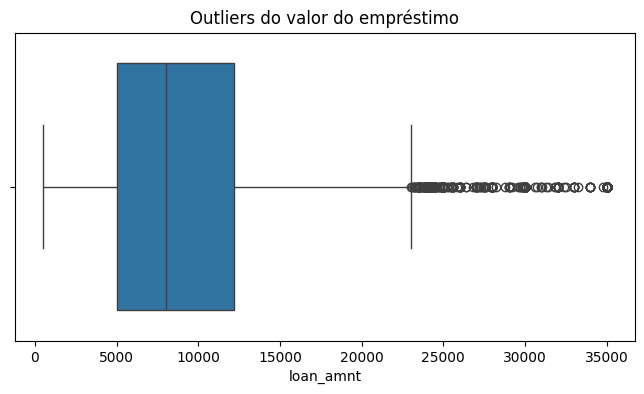

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["loan_amnt"])
plt.title("Outliers do valor do empréstimo")
plt.show()
#Esse gráfico será utilizado na Fase 2 para justificar o tratamento de outliers.

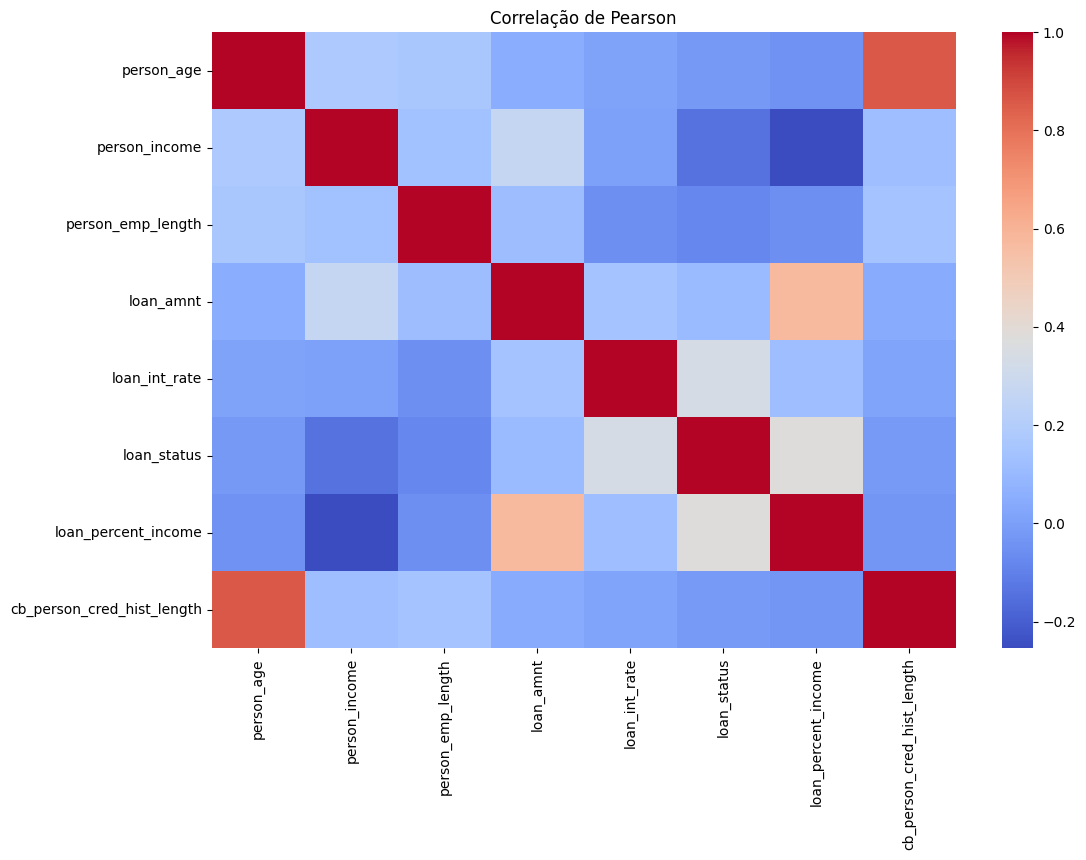

In [11]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlação de Pearson")
plt.show()

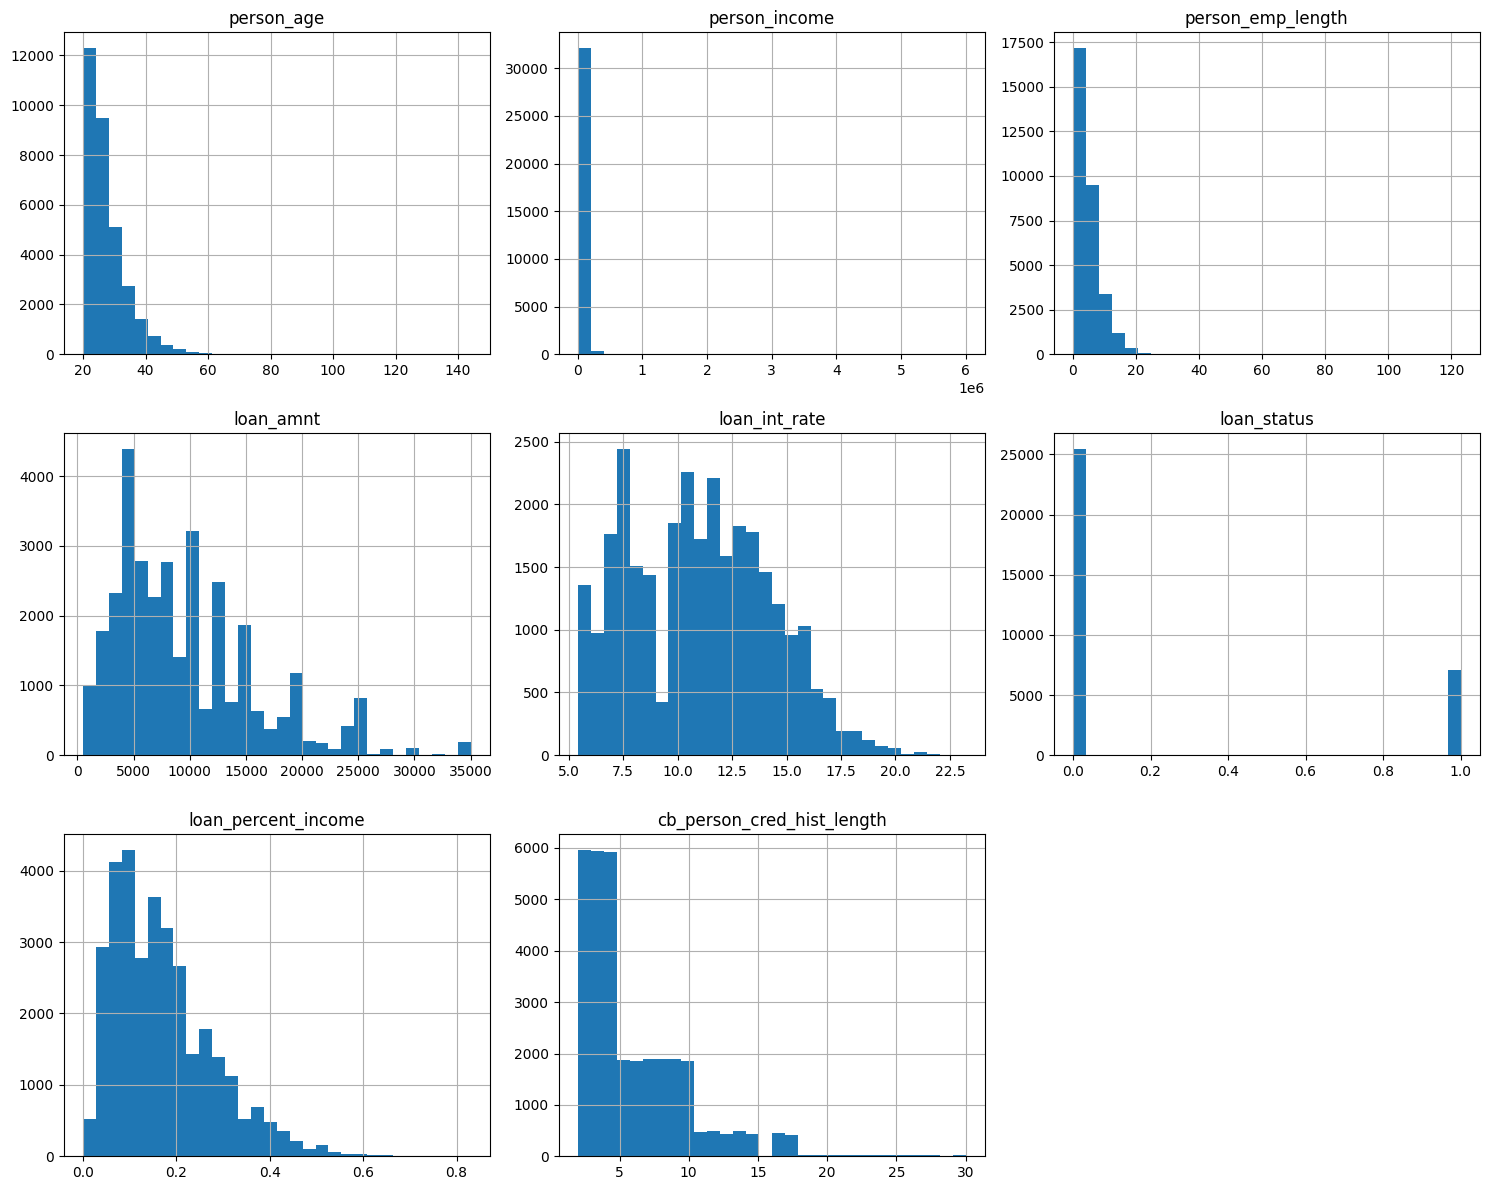

In [12]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()
#Distribuição das variáveis numéricas

A análise exploratória revelou a estrutura da base de dados, permitindo identificar os tipos das variáveis, a existência de valores ausentes e possíveis registros duplicados. A inspeção gráfica mostrou indícios de desbalanceamento na variável alvo e a presença de valores extremos em algumas variáveis numéricas, como renda e valor do empréstimo. O mapa de correlação indicou relações lineares moderadas entre algumas características, sem evidências iniciais de multicolinearidade severa. Essas observações orientarão as próximas etapas de tratamento dos dados, criação de atributos e treinamento dos modelos preditivos.